In [29]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
x,y=make_regression(n_samples=300,n_features=2,n_informative=2,n_targets=1,noise=50)

In [30]:
df=pd.DataFrame({'feature1':x[:,0],'feature2':x[:,1],'target':y})

In [31]:
df.shape

(300, 3)

In [32]:
df.head()

,feature1,feature2,target
0,1.983718,1.218165,229.229001
1,-0.539031,-1.454282,-197.071596
2,1.180499,0.448940,219.048892
3,-0.881529,1.531417,82.883201
4,-1.421675,0.690679,-29.675880


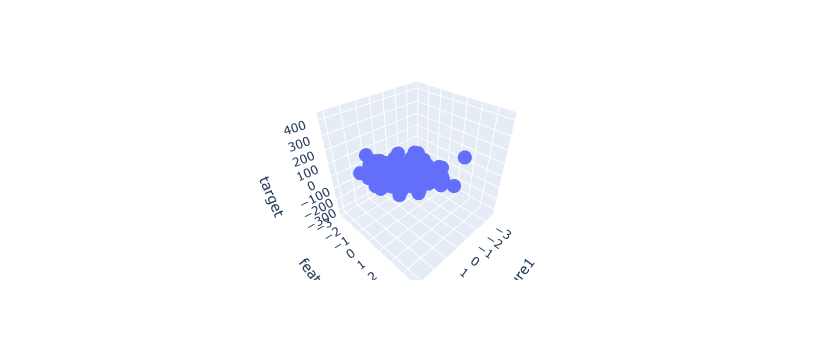

In [33]:
fig=px.scatter_3d(df,x="feature1",y="feature2",z="target")
fig.show()

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
lr=LinearRegression()

In [37]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[74.58,77.23]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8369
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[16.22,14.97]"


In [38]:
y_pred=lr.predict(x_test)

In [39]:
print("MAE: ",mean_absolute_error(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("R2 score: ",r2_score(y_test,y_pred))

MAE:  35.532980117958104
MSE:  2126.816624078457
R2 score:  0.8957771840080645


In [ ]:
# Create values for the two features
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

# Create 2D grid
xGrid, yGrid = np.meshgrid(x, y)

# Convert grid into 100 rows with 2 features
final = np.vstack((
    xGrid.ravel(),
    yGrid.ravel()
)).T

# Predict target values
z = lr.predict(final).reshape(10, 10)

# Plot original data
fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='target'
)

# Add regression plane
fig.add_trace(
    go.Surface(
        x=x,
        y=y,
        z=z
    )
)

fig.show()

In [46]:
# from sklearn.linear_model import LinearRegression

# lr = LinearRegression()

# lr.fit(X_train, y_train)

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(x, y)

final = np.vstack((
    xGrid.ravel(),
    yGrid.ravel()
)).T

z = lr.predict(final).reshape(10, 10)

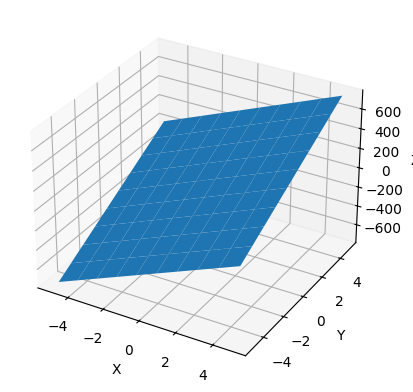

In [49]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xGrid, yGrid, z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
# 
plt.show()

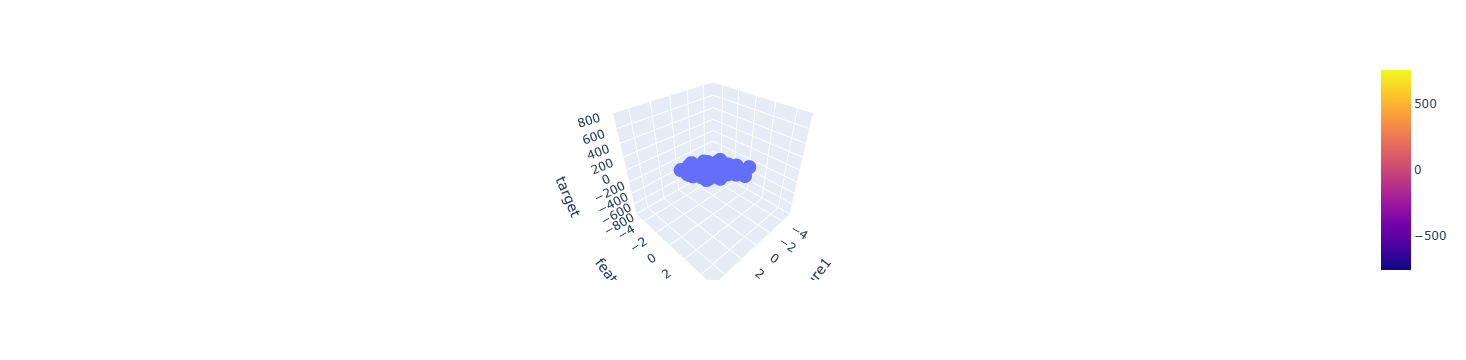

In [50]:

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

z_final = lr.predict(final).reshape(10,10)

z = z_final

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()